# Importing Data

In [ ]:
import pandas as pd
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display

from google.colab import drive

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC

from sklearn.metrics import (
 accuracy_score, classification_report, confusion_matrix,
 precision_score, recall_score, f1_score
)

import joblib # for saving the model

# Mounting Google Drive and Loading Files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/Speech_emotion_recognition/RAVDESS"
files = glob.glob(os.path.join(DATA_PATH, "Actor_*", "*.wav"))

print("Total audio files found:", len(files))
print("Sample file:", files[0])

Mounted at /content/drive
Total audio files found: 1440
Sample file: /content/drive/MyDrive/Speech_emotion_recognition/RAVDESS/Actor_24/03-01-01-01-02-02-24.wav


# Emotion Dictionary

In [ ]:
emotion_dict = {
 "01": "neutral",
 "02": "calm",
 "03": "happy",
 "04": "sad",
 "05": "angry",
 "06": "fearful",
 "07": "disgust",
 "08": "surprised"
}

# Building the Dataframe

In [ ]:
data = []

for file in files:
    filename = os.path.basename(file)
    parts = filename.replace(".wav", "").split("-")
    modality = parts[0]
    vocal_channel = parts[1]
    emotion_code = parts[2]
    intensity = parts[3]
    statement = parts[4]
    repetition = parts[5]
    actor = parts[6]

    data.append({
        "path": file,
        "filename": filename,
        "modality": modality,
        "vocal_channel": vocal_channel,
        "emotion_code": emotion_code,
        "emotion": emotion_dict[emotion_code],
        "intensity": intensity,
        "statement": statement,
        "repetition": repetition,
        "actor": int(actor)
  })

df = pd.DataFrame(data)
df.head()


,path,filename,modality,vocal_channel,emotion_code,emotion,intensity,statement,repetition,actor
0,/content/drive/MyDrive/Speech_emotion_recognit...,03-01-01-01-02-02-24.wav,03,01,01,neutral,01,02,02,24
1,/content/drive/MyDrive/Speech_emotion_recognit...,03-01-01-01-01-01-24.wav,03,01,01,neutral,01,01,01,24
2,/content/drive/MyDrive/Speech_emotion_recognit...,03-01-01-01-01-02-24.wav,03,01,01,neutral,01,01,02,24
3,/content/drive/MyDrive/Speech_emotion_recognit...,03-01-02-01-01-02-24.wav,03,01,02,calm,01,01,02,24
4,/content/drive/MyDrive/Speech_emotion_recognit...,03-01-02-01-01-01-24.wav,03,01,02,calm,01,01,01,24


# Emotion Distribution

--- Emotion Distribution ---
emotion
calm         192
happy        192
sad          192
angry        192
disgust      192
fearful      192
surprised    192
neutral       96
Name: count, dtype: int64

Unique actors: 24


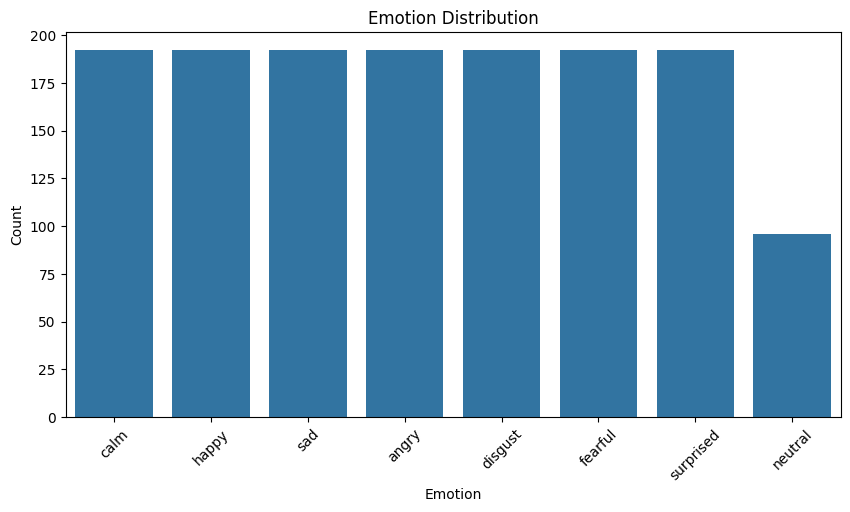

In [ ]:
print("--- Emotion Distribution ---")
print(df['emotion'].value_counts())
print("\nUnique actors:", df['actor'].nunique())

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="emotion", order=df["emotion"].value_counts().index)
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# MFCC Extraction

In [ ]:
def extract_mfcc_features(file_path, n_mfcc=40):
 # Load audio
 signal, sr = librosa.load(file_path, sr=22050)

 # Silence trimming (removes leading/trailing quiet sections)
 signal, _ = librosa.effects.trim(signal, top_db=20)

 # Amplitude normalization (zero mean, unit variance)
 if np.std(signal) > 0:
    signal = (signal - np.mean(signal)) / np.std(signal)

 # Extract MFCCs
 mfcc = librosa.feature.mfcc(
    y=signal, sr=sr, n_mfcc=n_mfcc,
    n_fft=2048, hop_length=512
 )

 # Aggregate across time axis to get fixed-length vector
 mfcc_mean = np.mean(mfcc, axis=1) # 40 values
 mfcc_std = np.std(mfcc, axis=1) # 40 values

 # Concatenate to single feature vector (80-dim)
 feature_vector = np.concatenate([mfcc_mean, mfcc_std])

 return feature_vector

# Building Feature Arrays

In [ ]:
X = []
y = []

print("Extracting MFCC features from", len(df), "audio files...")

for i in range(len(df)):
    if i % 100 == 0:
        print(f"Processing {i}/{len(df)}")

    file_path = df.loc[i, "path"]
    label = df.loc[i, "emotion"]

    feature = extract_mfcc_features(file_path)
    X.append(feature)
    y.append(label)

X = np.array(X)
y = np.array(y)

Extracting MFCC features from 1440 audio files...
Processing 0/1440
Processing 100/1440
Processing 200/1440
Processing 300/1440
Processing 400/1440
Processing 500/1440
Processing 600/1440
Processing 700/1440
Processing 800/1440
Processing 900/1440
Processing 1000/1440
Processing 1100/1440
Processing 1200/1440
Processing 1300/1440
Processing 1400/1440


# MFCC Feature Visualization

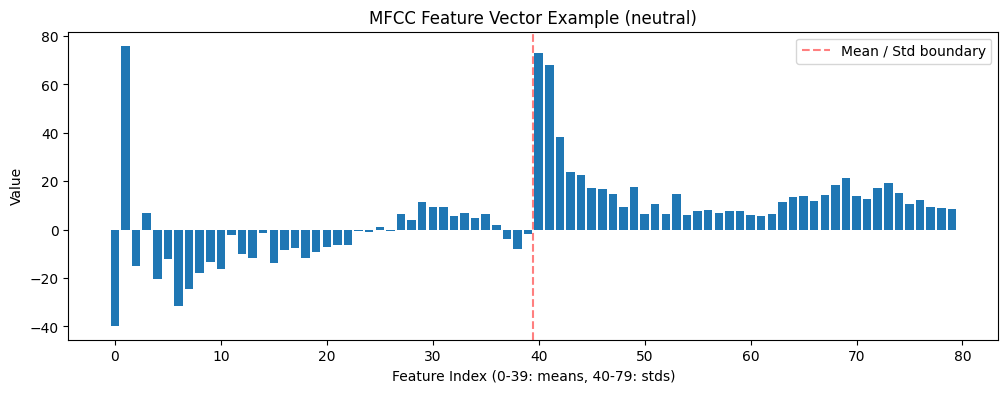

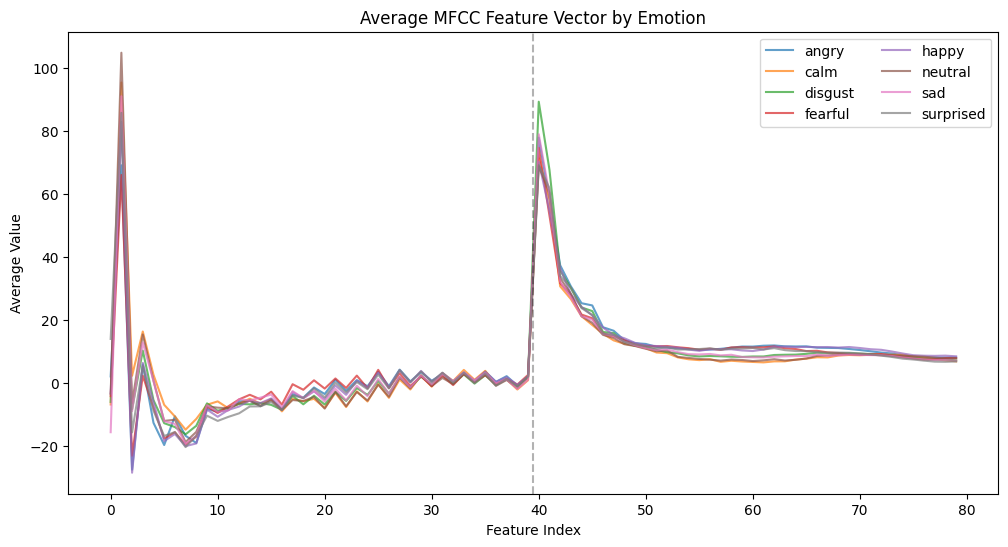

In [ ]:
# Show one sample's feature vector
plt.figure(figsize=(12, 4))
plt.bar(range(80), X[0])
plt.title(f"MFCC Feature Vector Example ({y[0]})")
plt.xlabel("Feature Index (0-39: means, 40-79: stds)")
plt.ylabel("Value")
plt.axvline(x=39.5, color='red', linestyle='--', alpha=0.5, label='Mean / Std boundary')
plt.legend()
plt.show()

# Plot average MFCC patterns by emotion
fig, ax = plt.subplots(figsize=(12, 6))
for emotion in np.unique(y):
    mask = y == emotion
    avg_mfcc = X[mask].mean(axis=0)
    ax.plot(avg_mfcc, label=emotion, alpha=0.7)

ax.axvline(x=39.5, color='black', linestyle='--', alpha=0.3)
ax.set_title("Average MFCC Feature Vector by Emotion")
ax.set_xlabel("Feature Index")
ax.set_ylabel("Average Value")
ax.legend(loc='best', ncol=2)
plt.show()


# Label Encoding

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Class order:", label_encoder.classes_)
print("y_encoded sample:", y_encoded[:10])


Class order: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
y_encoded sample: [5 5 5 1 1 5 1 4 4 1]


# Train/Test Split (Per-Speaker)

In [ ]:
# Per-speaker split: separate actors into train/test groups
np.random.seed(42)
all_actors = df['actor'].unique() # 24 actors total
np.random.shuffle(all_actors)

# Use 19 actors for training, 5 for testing (~80/20 split)
train_actors = all_actors[:19]
test_actors = all_actors[19:]
print(f"Training actors ({len(train_actors)}): {sorted(train_actors)}")
print(f"Testing actors ({len(test_actors)}): {sorted(test_actors)}")

# Create masks based on actor assignment
train_mask = df['actor'].isin(train_actors).values
test_mask = df['actor'].isin(test_actors).values
X_train = X[train_mask]
X_test = X[test_mask]
y_train = y_encoded[train_mask]
y_test = y_encoded[test_mask]

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


Training actors (19): [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(11), np.int64(12), np.int64(13), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(21), np.int64(22), np.int64(24)]
Testing actors (5): [np.int64(4), np.int64(10), np.int64(14), np.int64(20), np.int64(23)]

X_train shape: (1140, 80)
X_test shape: (300, 80)
y_train shape: (1140,)
y_test shape: (300,)


# Feature Standardization

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set mean (should be ~0):", X_train_scaled.mean().round(4))
print("Training set std (should be ~1):", X_train_scaled.std().round(4))


Training set mean (should be ~0): 0.0
Training set std (should be ~1): 1.0


# Hyperparameter Tuning (Grid Search)

In [ ]:
# Define hyperparameter search space
param_grid = {
 'C': [0.1, 1, 10, 100],
 'gamma': [0.001, 0.01, 0.1, 1, 'scale'],
 'kernel': ['rbf']
}

# 5-fold stratified cross-validation, scored by macro F1
# (macro F1 ensures balanced performance across all 8 emotions)
grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

print("Running grid search... (this takes 2-5 minutes)")
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")


Running grid search... (this takes 2-5 minutes)
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1 score: 0.4832


# SVM Model Training

In [ ]:
# Use the best estimator from grid search
svm_model = grid_search.best_estimator_\

# Re-fit on full training data (already done by GridSearchCV with refit=True default)
# This gives us the final model ready for evaluation
print("Final model:")
print(svm_model)

# Add probability=True if you want confidence scores for the real-time pipeline
# Note: This requires retraining, so do it once at the end
svm_model_with_proba = SVC(**grid_search.best_params_, probability=True, random_state=42)
svm_model_with_proba.fit(X_train_scaled, y_train)
print("\nFinal model trained with probability estimates enabled.")

Final model:
SVC(C=100, random_state=42)

Final model trained with probability estimates enabled.


# Model Performance Evaluation

In [ ]:
# Predict on test set
y_pred = svm_model.predict(X_test_scaled)

# Compute all primary metrics
accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')
precision_weighted = precision_score(y_test, y_pred, average='weighted')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print("=" * 50)
print("SVM Test Set Performance")
print("=" * 50)
print(f"Accuracy: {accuracy:.4f}")
print(f"\nMacro-Averaged (treats all emotions equally):")
print(f" Precision: {precision_macro:.4f}")
print(f" Recall: {recall_macro:.4f}")
print(f" F1-Score: {f1_macro:.4f}")
print(f"\nWeighted-Averaged (accounts for class distribution):")
print(f" Precision: {precision_weighted:.4f}")
print(f" Recall: {recall_weighted:.4f}")
print(f" F1-Score: {f1_weighted:.4f}")

print("\n" + "=" * 50)
print("Per-Class Classification Report")
print("=" * 50)

print(classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_
))


SVM Test Set Performance
Accuracy: 0.3967

Macro-Averaged (treats all emotions equally):
 Precision: 0.3763
 Recall: 0.3719
 F1-Score: 0.3506

Weighted-Averaged (accounts for class distribution):
 Precision: 0.4014
 Recall: 0.3967
 F1-Score: 0.3740

Per-Class Classification Report
              precision    recall  f1-score   support

       angry       0.48      0.35      0.41        40
        calm       0.55      0.28      0.37        40
     disgust       0.64      0.45      0.53        40
     fearful       0.27      0.62      0.38        40
       happy       0.23      0.12      0.16        40
     neutral       0.00      0.00      0.00        20
         sad       0.31      0.35      0.33        40
   surprised       0.52      0.80      0.63        40

    accuracy                           0.40       300
   macro avg       0.38      0.37      0.35       300
weighted avg       0.40      0.40      0.37       300



# Confusion Matrix Plot

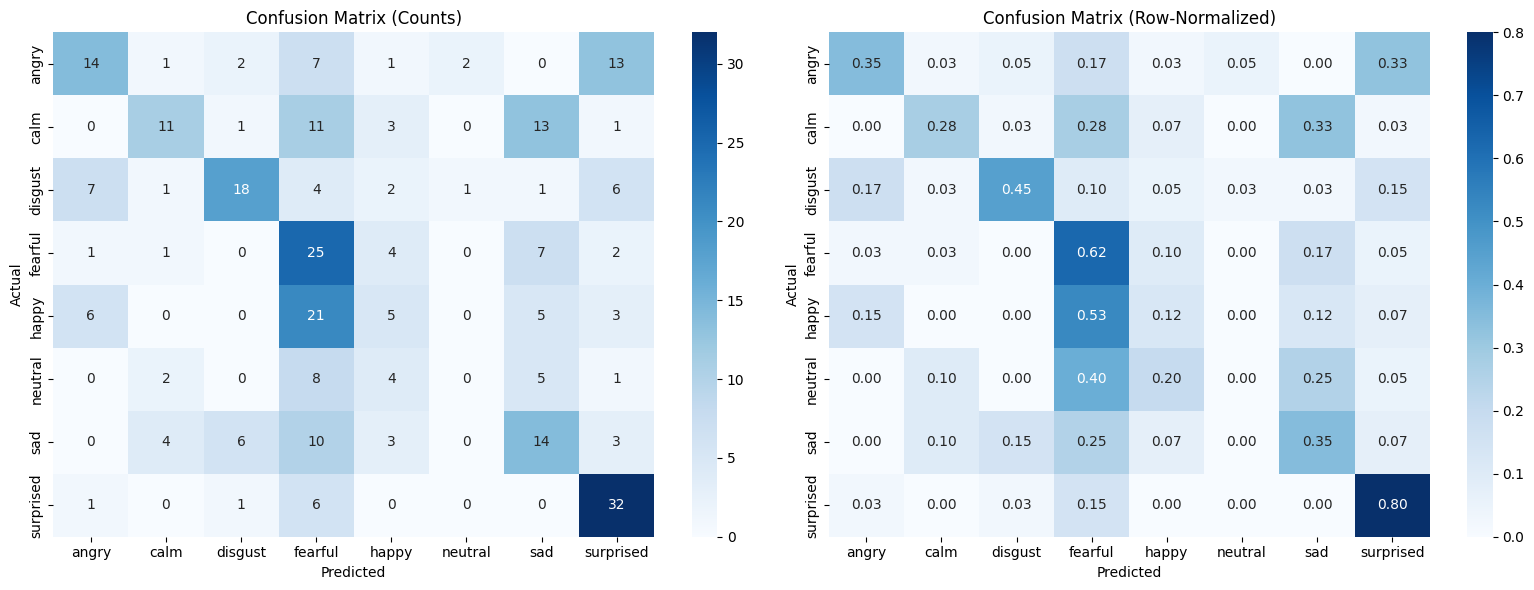

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

# Plot both confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    ax=axes[0]
)

axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Row-normalized (proportions)
sns.heatmap(
    cm_normalized, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    ax=axes[1]
)

axes[1].set_title("Confusion Matrix (Row-Normalized)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Cross-Validation Analysis

In [ ]:
from sklearn.model_selection import cross_val_score

# Run 5-fold cross-validation on the full dataset (using best hyperparameters)
# Standardize within each fold to avoid data leakage
from sklearn.pipeline import Pipeline
cv_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(**grid_search.best_params_, random_state=42))
])

# Use full feature set (training + test) for cross-validation
X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])

cv_scores_acc = cross_val_score(cv_pipeline, X_all, y_all, cv=5, scoring='accuracy')
cv_scores_f1 = cross_val_score(cv_pipeline, X_all, y_all, cv=5, scoring='f1_macro')

print("5-Fold Cross-Validation Results:")
print(f" Accuracy: {cv_scores_acc.mean():.4f} (+/- {cv_scores_acc.std():.4f})")
print(f" F1 Macro: {cv_scores_f1.mean():.4f} (+/- {cv_scores_f1.std():.4f})")
print(f"\n Individual fold accuracies: {cv_scores_acc.round(4)}")

# Save scores for statistical comparison with CNN/LSTM later
np.save("/content/svm_cv_acc.npy", cv_scores_acc)
np.save("/content/svm_cv_f1.npy", cv_scores_f1)
print("\nCV scores saved for cross-model statistical testing.")

5-Fold Cross-Validation Results:
 Accuracy: 0.4944 (+/- 0.0431)
 F1 Macro: 0.4780 (+/- 0.0527)

 Individual fold accuracies: [0.4792 0.4722 0.5208 0.5625 0.4375]

CV scores saved for cross-model statistical testing.


# Exporting the Final Model

In [ ]:
# Save model artifacts to Drive
SAVE_PATH = "/content/drive/MyDrive/Speech_emotion_recognition/models/"
os.makedirs(SAVE_PATH, exist_ok=True)

joblib.dump(svm_model_with_proba, SAVE_PATH + "svm_model.pkl")
joblib.dump(scaler, SAVE_PATH + "scaler.pkl")
joblib.dump(label_encoder, SAVE_PATH + "label_encoder.pkl")

print("Saved files:")
print(f" - {SAVE_PATH}svm_model.pkl")
print(f" - {SAVE_PATH}scaler.pkl")
print(f" - {SAVE_PATH}label_encoder.pkl")

# Verify by loading and testing
loaded_model = joblib.load(SAVE_PATH + "svm_model.pkl")
loaded_scaler = joblib.load(SAVE_PATH + "scaler.pkl")
loaded_encoder = joblib.load(SAVE_PATH + "label_encoder.pkl")

# Test with one sample
sample_features = X_test[0:1]
sample_scaled = loaded_scaler.transform(sample_features)
prediction = loaded_model.predict(sample_scaled)[0]
probabilities = loaded_model.predict_proba(sample_scaled)[0]

print(f"\nVerification - Sample prediction:")
print(f" Predicted: {loaded_encoder.classes_[prediction]}")
print(f" Confidence: {probabilities.max() * 100:.1f}%")
print(f" Actual: {loaded_encoder.classes_[y_test[0]]}")

Saved files:
 - /content/drive/MyDrive/Speech_emotion_recognition/models/svm_model.pkl
 - /content/drive/MyDrive/Speech_emotion_recognition/models/scaler.pkl
 - /content/drive/MyDrive/Speech_emotion_recognition/models/label_encoder.pkl

Verification - Sample prediction:
 Predicted: angry
 Confidence: 57.8%
 Actual: happy


# Export Summary Statistics

In [ ]:
import pandas as pd

print("Building summary_stats.csv...")
summary_rows = []

for i, row in df.iterrows():
    if i % 100 == 0:
        print(f" Processing {i}/{len(df)}")

    file_path = row["path"]
    emotion = row["emotion"]

    # Load audio (same settings as the model pipeline)
    signal, sr = librosa.load(file_path, sr=22050)
    signal, _ = librosa.effects.trim(signal, top_db=20)

    # 40 MFCC means
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40,
    n_fft=2048, hop_length=512)
    mfcc_means = np.mean(mfcc, axis=1)

    # Average pitch (filter out frames with no detected pitch)
    pitches, magnitudes = librosa.piptrack(y=signal, sr=sr)
    nonzero_pitches = pitches[pitches > 0]
    avg_pitch = float(np.mean(nonzero_pitches)) if nonzero_pitches.size > 0 else 0.0

    # Build the row
    row_dict = {"emotion": emotion, "pitch": avg_pitch}

    for j, val in enumerate(mfcc_means):
        row_dict[f"mfcc_{j+1}"] = float(val)

    summary_rows.append(row_dict)

summary_df = pd.DataFrame(summary_rows)

# Save to Drive (so your teammate can download it)
SAVE_PATH = "/content/drive/MyDrive/Speech_emotion_recognition/data/"
summary_df.to_csv(SAVE_PATH + "summary_stats.csv", index=False)

print(f"\nSaved {len(summary_df)} rows to {SAVE_PATH}summary_stats.csv")
print("\nFirst 3 rows:")
print(summary_df.head(3))
print("\nPer-emotion averages:")
print(summary_df.groupby("emotion").mean(numeric_only=True)[["pitch", "mfcc_1", "mfcc_2"]])

Building summary_stats.csv...
 Processing 0/1440
 Processing 100/1440
 Processing 200/1440
 Processing 300/1440
 Processing 400/1440
 Processing 500/1440
 Processing 600/1440
 Processing 700/1440
 Processing 800/1440
 Processing 900/1440
 Processing 1000/1440
 Processing 1100/1440
 Processing 1200/1440
 Processing 1300/1440
 Processing 1400/1440

Saved 1440 rows to /content/drive/MyDrive/Speech_emotion_recognition/summary_stats.csv

First 3 rows:
   emotion        pitch      mfcc_1     mfcc_2     mfcc_3    mfcc_4  \
0  neutral  1247.479736 -500.692505  75.997772 -15.167946  7.063635   
1  neutral  1379.222290 -530.400452  87.869675 -16.908449  0.527730   
2  neutral  1534.970703 -511.814941  82.621445 -28.590830  1.151875   

      mfcc_5     mfcc_6     mfcc_7     mfcc_8  ...   mfcc_31    mfcc_32  \
0 -20.454208 -12.231112 -31.337420 -24.678013  ...  9.499229   9.374622   
1 -17.294418 -17.038265 -23.262917 -24.998608  ...  8.779251  13.789276   
2 -19.143593 -21.825933 -21.661526 -27.

# Model Classification Report

In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

       angry       0.48      0.35      0.41        40
        calm       0.55      0.28      0.37        40
     disgust       0.64      0.45      0.53        40
     fearful       0.27      0.62      0.38        40
       happy       0.23      0.12      0.16        40
     neutral       0.00      0.00      0.00        20
         sad       0.31      0.35      0.33        40
   surprised       0.52      0.80      0.63        40

    accuracy                           0.40       300
   macro avg       0.38      0.37      0.35       300
weighted avg       0.40      0.40      0.37       300

